## Run a pipeline

### Minimal Pipeline Execution: Runs in just **3 lines of code**

```python
from paidiverpy.pipeline import Pipeline
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")
pipeline.run()
```

### This is the configuration file:


```yaml
general:
  sample_data: "benthic_ifdo"
  output_path: "./output"
  n_jobs: 8
  sampling:
    - mode: "fixed"
      params:
        value: 5
  convert:
    - mode: "bits"
      params:
        output_bits: 8
steps:
  - colour:
      name: "colour_correction"
      mode: "grayscale"

  - sampling:
      name: "datetime"
      mode: "datetime"
      params:
        min: "2016-05-11 04:14:00"
        max: "2016-05-11 09:27:00"

  - colour:
      name: "colour_correction"
      mode: "gaussian_blur"
      params:
        sigma: 1.0

  - colour:
      name: "sharpen"
      mode: "sharpen"
      params:
        alpha: 1.5
        beta: -0.5

  - colour:
      name: "contrast"
      mode: "contrast"
```

### Sample data

This configuration file uses a part of our example data:

```yaml
general:
  sample_data: "benthic_ifdo"
```

In this case, it will download the data automatically. But you can also do it manually:

In [1]:
from paidiverpy.utils.data import PaidiverpyData

data = PaidiverpyData()
data.load("benthic_ifdo")

{'input_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/images',
 'metadata_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/metadata/metadata_benthic_ifdo.json',
 'metadata_type': 'IFDO',
 'image_open_args': 'JPG'}

## Running the code

In [2]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

In [3]:
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")

☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:24 | No dataset UUID found in the dataset metadata. A new UUID has been generated: 465ff2e3-b036-49e4-8d28-9e61c08d875a


In [4]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [5]:
# See the pipeline steps in json format
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 8,
        "track_changes": true,
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 20,
                    "raise_error": false
                },
                "mode": "fixed"
            }
        ]
    },
    "steps": [
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            },
            "mode": "grayscale"
        },
        {
            "name": "datetime",
            "step_name": "sampling",
            "test": false,
            "params": {
                "min": "2018-06-11 04:14:00",
                "max": "2018-06-11 04:20:00",
                "raise_error": false
            },
            "mode": "datetime"
        },
        {
            "name": "overlapping",
            "step_name": "sampling",
            "test": false,
            "params": {
                "omega": 57.0,
                "theta": 40.0,
                "threshold": 0.5,
                "camera_distance": 1.12,
                "raise_error": false
            },
            "mode": "overlapping"
        },
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "sigma": 1.0,
                "raise_error": false
            },
            "mode": "gaussian_blur"
        },
        {
            "name": "sharpen",
            "step_name": "colour",
            "test": false,
            "params": {
                "alpha": 1.5,
                "beta": -0.5,
                "raise_error": false
            },
            "mode": "sharpen"
        },
        {
            "name": "contrast",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "clahe",
                "clip_limit": 0.01,
                "gamma_value": 0.5,
                "raise_error": false
            },
            "mode": "contrast"
        }
    ]
}

In [6]:
%%time
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:28 | No dataset UUID found in the dataset metadata. A new UUID has been generated: 4c922085-f8a0-4e08-8582-6575766344ed
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:28 | Processing images using 8 cores
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:28 | Running step 0: raw - OpenLayer
[########################################] | 100% Completed | 101.92 ms
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:29 | Step 0 completed
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:29 | Running step 1: colour_correction - ColourLayer
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:29 | Step 1 completed
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:29 | Running step 2: datetime - SamplingLayer
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:29 | Number of images before the sampling step: 20. Total number of images after: 11
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:29 | Step 2 completed
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:29 |

In [7]:
pipeline.images.images["images_0"]

<xarray.DataArray 'images_0' (filename: 20, y_0: 128, x_0: 128, band_0: 4)> Size: 1MB
array([[[[179, 189, 164, 255],
         [178, 189, 165, 255],
         [180, 190, 168, 255],
         ...,
         [209, 206, 161, 255],
         [210, 205, 161, 255],
         [210, 206, 164, 255]],

        [[181, 190, 166, 255],
         [180, 189, 165, 255],
         [179, 190, 169, 255],
         ...,
         [210, 204, 159, 255],
         [211, 206, 162, 255],
         [212, 206, 161, 255]],

        [[182, 190, 169, 255],
         [180, 189, 169, 255],
         [183, 190, 168, 255],
         ...,
...
         ...,
         [ 26,  62,  59, 255],
         [ 20,  62,  57, 255],
         [ 19,  57,  55, 255]],

        [[ 16,  48,  46, 255],
         [ 37,  51,  48, 255],
         [150, 133, 124, 255],
         ...,
         [ 20,  59,  55, 255],
         [ 23,  56,  55, 255],
         [ 20,  59,  56, 255]],

        [[ 10,  39,  39, 255],
         [150, 126, 117, 255],
         [160, 136, 125, 255],
         ...,
         [ 19,  55,  54, 255],
         [ 17,  55,  52, 255],
         [ 19,  55,  55, 255]]]], shape=(20, 128, 128, 4), dtype=uint8)
Coordinates: (12/19)
  * filename           (filename) <U18 1kB '20180611041421.png' ... '20180611...
  * y_0                (y_0) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
  * x_0                (x_0) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
  * band_0             (band_0) int64 32B 0 1 2 3
    original_height_0  (filename) int64 160B 128 128 128 128 ... 128 128 128 128
    original_width_0   (filename) int64 160B 128 128 128 128 ... 128 128 128 128
    ...                 ...
    original_height_4  (filename) int64 160B 128 128 128 128 ... 128 128 128 128
    original_width_4   (filename) int64 160B 128 128 128 128 ... 128 128 128 128
    original_height_5  (filename) int64 160B 128 128 128 128 ... 128 128 128 128
    original_width_5   (filename) int64 160B 128 128 128 128 ... 128 128 128 128
    original_height_6  (filename) int64 160B 128 128 128 128 ... 128 128 128 128
    original_width_6   (filename) int64 160B 128 128 128 128 ... 128 128 128 128


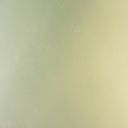
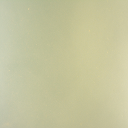
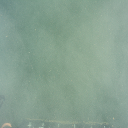
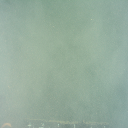
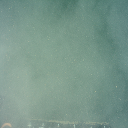
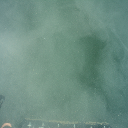
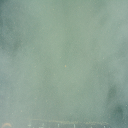
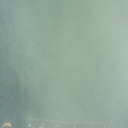
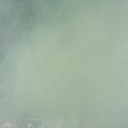
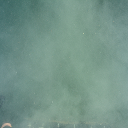
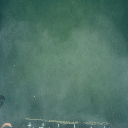
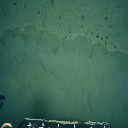
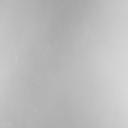
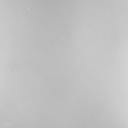
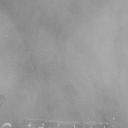
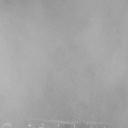
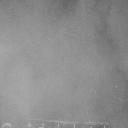
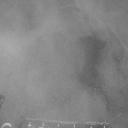
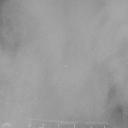
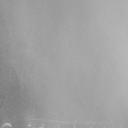
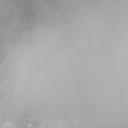
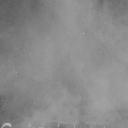
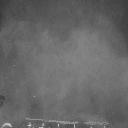
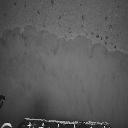
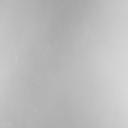
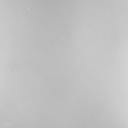
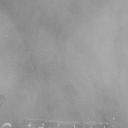
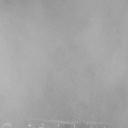
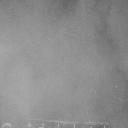
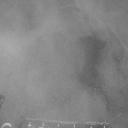
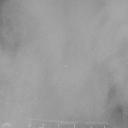
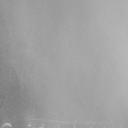
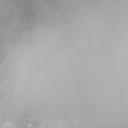
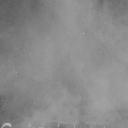
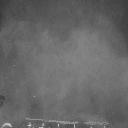
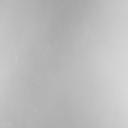
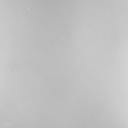
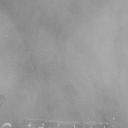
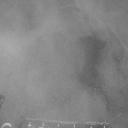
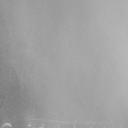
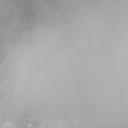
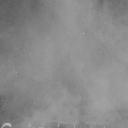
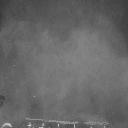
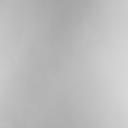
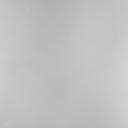
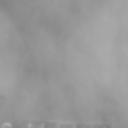
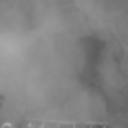
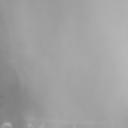
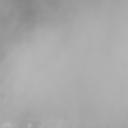
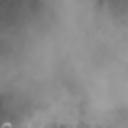
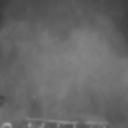
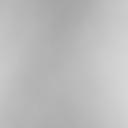
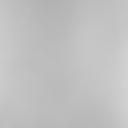
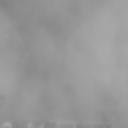
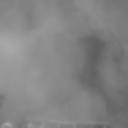
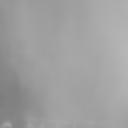
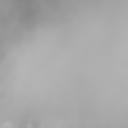
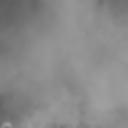
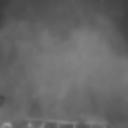
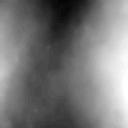
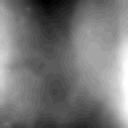
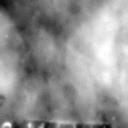
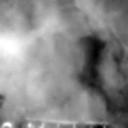
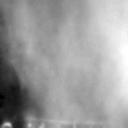
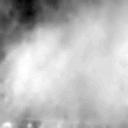
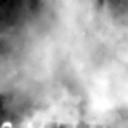
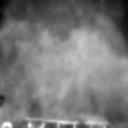

In [8]:
# See the images output
pipeline.images

In [9]:
pipeline.get_metadata("all")

,filename,ID,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,TRcornerlong,TRcornerlat,TLcornerlong,TLcornerlat,BLcornerlong,BLcornerlat,BRcornerlong,BRcornerlat,overlap,polygon_m
0,20180611041421.png,430,300,300,0.016667,8,200,2018-06-11 04:14:21,2.828427,FLASH,...,-153.605307,11.251713,-153.605307,11.251738,-153.605324,11.251739,-153.605325,11.251713,0.0,POLYGON ((-153.60530730838863 11.2517125679763...
1,20180611041501.png,434,300,300,0.016667,8,200,2018-06-11 04:15:01,2.828427,FLASH,...,-153.605305,11.251690,-153.605305,11.251716,-153.605323,11.251716,-153.605323,11.251690,0.0,POLYGON ((-153.60532287038686 11.2516901280594...
2,20180611041711.png,447,300,300,0.016667,8,200,2018-06-11 04:17:11,2.828427,FLASH,...,-153.605312,11.251618,-153.605312,11.251645,-153.605330,11.251645,-153.605330,11.251618,0.0,POLYGON ((-153.60531182829246 11.2516181498626...
3,20180611041731.png,449,300,300,0.016667,8,200,2018-06-11 04:17:31,2.828427,FLASH,...,-153.605309,11.251616,-153.605309,11.251642,-153.605327,11.251643,-153.605328,11.251616,1.0,POLYGON ((-153.60530948504496 11.2516156522718...
4,20180611041741.png,450,300,300,0.016667,8,200,2018-06-11 04:17:41,2.828427,FLASH,...,-153.605306,11.251616,-153.605306,11.251642,-153.605323,11.251642,-153.605324,11.251616,1.0,POLYGON ((-153.60530610784394 11.2516157947657...
5,20180611041751.png,451,300,300,0.016667,8,200,2018-06-11 04:17:51,2.828427,FLASH,...,-153.605302,11.251615,-153.605302,11.251642,-153.605320,11.251642,-153.605320,11.251615,0.0,POLYGON ((-153.6053015951501 11.25161483159092...
6,20180611041801.png,452,300,300,0.016667,8,200,2018-06-11 04:18:01,2.828427,FLASH,...,-153.605299,11.251615,-153.605299,11.251641,-153.605316,11.251641,-153.605317,11.251615,1.0,POLYGON ((-153.60529932432337 11.2516151158048...
7,20180611041811.png,453,300,300,0.016667,8,200,2018-06-11 04:18:11,2.828427,FLASH,...,-153.605289,11.251617,-153.605289,11.251647,-153.605309,11.251647,-153.605309,11.251617,0.0,POLYGON ((-153.6053089846491 11.25161735210587...
8,20180611041831.png,455,300,300,0.016667,8,200,2018-06-11 04:18:31,2.828427,FLASH,...,-153.605277,11.251621,-153.605277,11.251646,-153.605294,11.251646,-153.605294,11.251621,0.0,POLYGON ((-153.605277424527 11.251621334935358...
9,20180611041841.png,456,300,300,0.016667,8,200,2018-06-11 04:18:41,2.828427,FLASH,...,-153.605268,11.251624,-153.605268,11.251651,-153.605286,11.251652,-153.605287,11.251624,0.0,POLYGON ((-153.60526798471008 11.2516238013981...



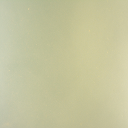
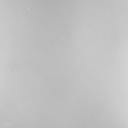
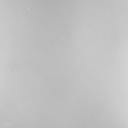
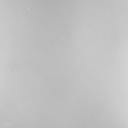
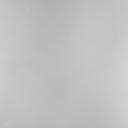
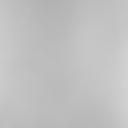
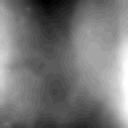

In [10]:
pipeline.images.show(image_number=1)

# Export Images to file

In [11]:
pipeline.save_images(image_format="png")

☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:41 | Saving images from step: last
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:41 | Saving images using Threads
☁ paidiverpy ☁  |       INFO | 2025-09-16 11:43:41 | Images are saved to: output
